In [1]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def check_overfitting(model, X_train, X_test, y_train, y_test, model_name="Model"):

    # 預測
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 計算 R²
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # MSE / RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Overfitting Check")
    print(f"Train R²: {train_r2:.3f}")
    print(f"Test  R²: {test_r2:.3f}")
    print(f"Train RMSE: {train_rmse:.3f}")
    print(f"Test  RMSE: {test_rmse:.3f}")

    # 判斷
    if train_r2 - test_r2 > 0.10 and train_r2 > 0.80:
        print("判定：Overfitting")
    elif test_r2 < 0.20 and train_r2 > test_r2:
        print("高度懷疑")
    else:
        print("未過擬合")

    return train_r2, test_r2


C:\Users\sara9\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 1) 讀取 & 篩選
# =========================
df = pd.read_csv('NBA_Normalized_Final.csv')
bool_cols = [
    'Is_Undrafted',
    'Pos_PG',
    'Pos_C',
    'Pos_SG',
    'Pos_SF',
    'Pos_PF'
]   
for col in bool_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.upper()
        .map({"TRUE": 1, "FALSE": 0})
    )

df_g = df[
    (df['season'] > 1)&(df['year_start']>1999)
]

feature_cols=['G','2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM','DRB','DRB%','DWS','FG','FG%','FGA','FT','FT%','FTA','FTr','OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG','Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%','VORP','WS','WS/48','eFG%']
target_col = 'Year4_WS'


data = df_g.dropna(subset=feature_cols + [target_col])

X = data[feature_cols]
y = data[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2) 定義評估函數
# =========================
def eval_regression(y_true, y_pred, name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n[{name}]")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)
    return rmse, mae, r2

# =========================
# 3) Random Forest + 隨機搜尋調參
# =========================
rf = RandomForestRegressor(random_state=42, n_jobs=-1)



param_dist = {
    
    "max_depth": [3, 4, 5, 6], 
    "min_samples_leaf": [10, 15, 20, 30], 
    "min_samples_split": [20, 30, 50],
    "max_features": ["sqrt", "log2", 0.3], 
    "n_estimators": [300, 500],
    "bootstrap": [True] 
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                      
    scoring="r2",  
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

search.fit(X_train, y_train)

# =========================
# 4) 輸出最佳參數與 CV 表現
# =========================
print("\nBest Params:")
print(search.best_params_)

best_r2_cv = search.best_score_
print("\nBest CV R^2:", best_r2_cv)

# =========================
# 5) 用最佳模型做 train/test 評估
# =========================
best_model = search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

eval_regression(y_train, y_pred_train, "Best RF - Train")
eval_regression(y_test, y_pred_test, "Best RF - Test")

train_r2 = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_r2 = np.sqrt(mean_squared_error(y_test, y_pred_test))


# =========================
# 6) 特徵重要度
# =========================
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Params:
{'n_estimators': 500, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 5, 'bootstrap': True}

Best CV R^2: 0.46406441761918166

[Best RF - Train]
RMSE: 1.7577205902100017
MAE : 1.349208419029154
R²  : 0.6000631982509532

[Best RF - Test]
RMSE: 2.054252405253879
MAE : 1.5547921994415588
R²  : 0.4226767935983279

Feature Importances (Top 10):
WS       0.307887
OWS      0.162936
VORP     0.148184
DWS      0.072334
FTA      0.032490
FT       0.030580
PER      0.027411
BPM      0.023064
WS/48    0.016497
OBPM     0.013214
dtype: float64


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Spearman
def spearman_corr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # rank
    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    rt = rankdata(y_true)
    rp = rankdata(y_pred)

    # 皮爾森相關
    rt = rt - rt.mean()
    rp = rp - rp.mean()
    denom = np.sqrt((rt**2).sum() * (rp**2).sum())
    return float((rt * rp).sum() / denom) if denom != 0 else np.nan


def evaluate_with_best_params(
    model_type,               
    best_params,              
    X_All, y_All,
    test_size=0.2,
    random_state=42,
    cv_splits=5
):
 

    X_train, X_test, y_train, y_test = train_test_split(
        X_All, y_All, test_size=test_size, random_state=random_state
    )


    if model_type == "rf":
        model = RandomForestRegressor(random_state=random_state, n_jobs=-1, **best_params)
    elif model_type == "gbr":
        model = GradientBoostingRegressor(random_state=random_state, **best_params)
    else:
        raise ValueError("model_type 只支援 'rf' 或 'gbr'")


    model.fit(X_train, y_train)


    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_test = mean_absolute_error(y_test, y_test_pred)
    medae_test = median_absolute_error(y_test, y_test_pred)

    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    cv_rmse = -cv_scores
    cv_rmse_mean = cv_rmse.mean()
    cv_rmse_std  = cv_rmse.std(ddof=1)


    rmse_gap = rmse_test - rmse_train   # >0 通常代表 test 比 train 差（正常，但太大可能 overfit）


    spearman = spearman_corr(y_test, y_test_pred)



    print(f"RMSE (test): {rmse_test:.6f}")
    print(f"MAE  (test): {mae_test:.6f}")
    print(f"MedianAE (test): {medae_test:.6f}")
    print(f"CV RMSE (train, {cv_splits}-fold): {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}")
    print(f"Train–Test Gap (RMSE_test - RMSE_train): {rmse_gap:.6f}")
    print(f"Spearman rank corr (test): {spearman:.6f}")


    return {
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "medae_test": medae_test,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "rmse_gap": rmse_gap,
        "spearman_test": spearman
    }

best_params_rf = search.best_params_
results_rf = evaluate_with_best_params("rf", best_params_rf, X, y)
check_overfitting(best_model, X_train, X_test, y_train, y_test, "Random Forest")


Model: RF | Best params: {'n_estimators': 500, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 5, 'bootstrap': True}
RMSE (test): 2.054252
MAE  (test): 1.554792
MedianAE (test): 1.158692
CV RMSE (train, 5-fold): 2.012113 ± 0.095742
Train–Test Gap (RMSE_test - RMSE_train): 0.296532
Spearman rank corr (test): 0.625137

🔍 Random Forest Overfitting Check
--------------------------------------
Train R²: 0.600
Test  R²: 0.423
Train RMSE: 1.758
Test  RMSE: 2.054
✅ 未過擬合（泛化能力良好）


(0.6000631982509532, 0.4226767935983279)

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr

# =========================
# 1. 讀取與清理資料
# =========================
df_main = pd.read_csv("NBA_Normalized_Final.csv")

# 布林值轉換 (TRUE/FALSE -> 1/0)
bool_cols = ['Is_Undrafted']
for col in bool_cols:
    if col in df_main.columns:
        df_main[col] = df_main[col].astype(str).str.strip().str.upper().map({
            "TRUE": 1, "FALSE": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0
        }).fillna(0)


dummy_cols = ['Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in dummy_cols:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce').fillna(0)


target_col = "Year3_WS"
feature_cols = [
    '2P%', '2PA', '3P', '3P%', '3PA', '3PAr', 'AST', 'AST%', 'BLK', 'BLK%',
    'BPM', 'DBPM', 'DRB', 'DRB%', 'DWS', 'DraftRank', 'FG', 'FG%', 'FGA',
    'FT', 'FT%', 'FTA', 'FTr', 'OBPM', 'ORB', 'ORB%', 'OWS', 'PER', 'PF',
    'PTS', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG', 'STL', 'STL%',
    'TOV', 'TOV%', 'TRB', 'TRB%', 'TS%', 'USG%', 'VORP', 'WS', 'WS/48',
    'eFG%', 'Is_Undrafted'
]

# =========================
# 2. 篩選訓練集與預測集
# =========================
df_train = df_main[
    (df_main["year_start"] != 2007) & 
    (df_main["season"] > 1) & 
    (df_main[target_col].notna())
].copy()


df_2007 = df_main[
    (df_main["year_start"] == 2007) & 
    (df_main["season"] > 1) & 
    (df_main['DraftRank'] <= 30)
].copy()


for col in feature_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
    df_2007[col] = pd.to_numeric(df_2007[col], errors='coerce')
df_train[target_col] = pd.to_numeric(df_train[target_col], errors='coerce')

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_pred = df_2007[feature_cols]

# =========================
# 3. 建立並訓練 Random Forest 模型
# =========================

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

final_model.fit(X_train, y_train)

# =========================
# 4. 預測與價值計算
# =========================
df_2007["Pred_WS"] = final_model.predict(X_pred).ravel()


try:
    eco_ref = df_main[df_main["year_start"] == 2007].iloc[0]
    SALARY_CAP_2007 = eco_ref['Salary_Cap_At_Start']
    BRI_FACTOR_2007 = eco_ref['BRI_Factor']
    marginal_value_per_ws = (SALARY_CAP_2007 * 30 * BRI_FACTOR_2007) / 1230
except:
    SALARY_CAP_2007 = 55.63  
    marginal_value_per_ws = 2.45


df_2007["Pred_Dollar_Value_M"] = df_2007["Pred_WS"] * marginal_value_per_ws
df_2007["Pred_Salary_Share_Percent"] = (df_2007["Pred_Dollar_Value_M"] / SALARY_CAP_2007) * 100

def get_cost_percent(row):
    rank = row["DraftRank"]
    if 1 <= rank <= 30:
        return 8.0 - (rank - 1) * (6.5 / 29)
    return 1.1

df_2007["Est_Cost_Percent"] = df_2007.apply(get_cost_percent, axis=1)
df_2007["Net_Surplus_Percent"] = df_2007["Pred_Salary_Share_Percent"] - df_2007["Est_Cost_Percent"]
df_2007["Pred_ROI"] = df_2007["Pred_Salary_Share_Percent"] / df_2007["Est_Cost_Percent"]

# =========================
# 5. 輸出結果
# =========================
result = df_2007[[
    "Player", "DraftRank", "Pred_WS", "Year3_WS", 
    "Pred_Salary_Share_Percent", "Est_Cost_Percent", 
    "Net_Surplus_Percent", "Pred_ROI"
]].sort_values("Pred_WS", ascending=False)

print(f"訓練樣本數: {len(X_train)} | 預測樣本數: {len(X_pred)}")
print(result.to_string(index=False))

訓練樣本數: 1471 | 預測樣本數: 25

=== 2007年首輪秀：Random Forest 預測結果 (包含第三年缺失球員) ===
           Player  DraftRank  Pred_WS  Year3_WS  Pred_Salary_Share_Percent  Est_Cost_Percent  Net_Surplus_Percent  Pred_ROI
      Brandon Roy        6.0    7.076      13.5                  21.573171          6.879310            14.693860  3.135950
     Nene Hilario        7.0    6.766       3.2                  20.628049          6.655172            13.972876  3.099551
    Ronnie Brewer       14.0    6.290       6.8                  19.176829          5.086207            14.090622  3.770360
      Rajon Rondo       21.0    5.478       9.9                  16.701220          3.517241            13.183978  4.748386
LaMarcus Aldridge        2.0    5.444       9.5                  16.597561          7.775862             8.821699  2.134498
         Rudy Gay        8.0    4.185       3.3                  12.759146          6.431034             6.328112  1.983996
     Tyrus Thomas        4.0    3.557       4.6            

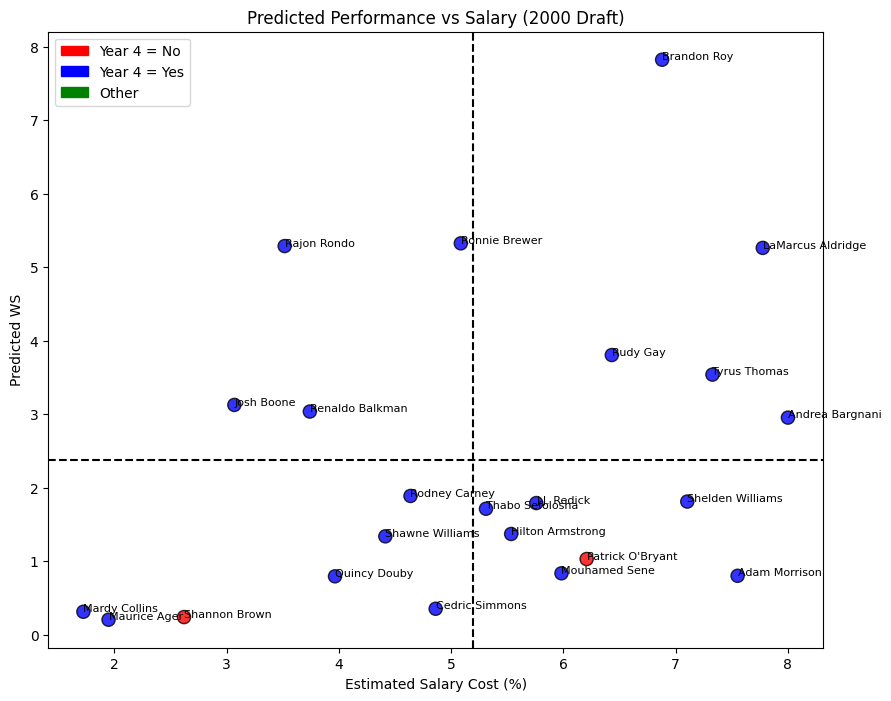

In [10]:

rmse_threshold = rmse_test

conditions = [
                    
    (df_2000["Net_Surplus_Percent"] < -rmse_threshold),     
    (df_2000["Net_Surplus_Percent"] > 0),                    
    (df_2000["Net_Surplus_Percent"] <= 0) & (df_2000["Net_Surplus_Percent"] >= -rmse_threshold) 
]
choices = [ "red", "blue", "green"]
colors = np.select(conditions, choices, default="gray")


plt.figure(figsize=(14, 10))

x = df_2000["Est_Cost_Percent"]
y = df_2000["Pred_WS"]

plt.scatter(x, y, c=colors, s=120, alpha=0.75, edgecolors="black", linewidth=1, zorder=3)

# 畫出 WS 止損線 
plt.axhline(ws_floor, color="red", linestyle=":", linewidth=2, alpha=0.6, label=f"WS Floor ({ws_floor})")

# 畫出原有的平均基準線
plt.axvline(x.mean(), color="black", linestyle="--", alpha=0.2)
plt.axhline(y.mean(), color="black", linestyle="--", alpha=0.2)

# 標註球員姓名
for i, row in df_2000.iterrows():
    plt.text(
        row["Est_Cost_Percent"] + 0.05, 
        row["Pred_WS"] + 0.05,
        row["Player"],
        fontsize=9,
        alpha=0.5 if (row["Pred_WS"] <= ws_floor or row["Net_Surplus_Percent"] < -rmse_threshold) else 0.9
    )

plt.xlabel("Estimated Option Strike Price (Salary Cost %)", fontsize=12)
plt.ylabel("Asset Valuation (Predicted Win Shares)", fontsize=12)
plt.title(f"Strategic Option Decision Analysis (RMSE={rmse_threshold}%, WS Floor={ws_floor})", fontsize=16)

# 圖例
blue_patch = mpatches.Patch(color='blue', label='🔵 Exercise: Profitable')
green_patch = mpatches.Patch(color='green', label='🟢 Exercise: Insurance Zone')
red_patch = mpatches.Patch(color='red', label='🔴 Expire: Performance/Economic Risk')
plt.legend(handles=[blue_patch, green_patch, red_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 輸出決策摘要 
print("建議放棄球員清單")
red_zone = df_2000[(df_2000["Net_Surplus_Percent"] < -rmse_threshold)]
print(red_zone[["Player", "DraftRank", "Pred_WS", "Net_Surplus_Percent"]].sort_values("Pred_WS"))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ==========================================
# 1. 準備數據與顏色映射
# ==========================================

df_2000['year_3_clean'] = df_2000['year_3'].astype(str).str.strip().str.lower()


color_map = {'yes': 'blue', 'no': 'red', 'x': 'blue'} 
df_2000['plot_color'] = df_2000['year_3_clean'].map(color_map).fillna('gray')


df_plot = df_2000.dropna(subset=['Year3_WS']).copy()

# ==========================================
# 2. 繪製實際決策圖表
# ==========================================
plt.figure(figsize=(14, 10))

x = df_plot["Est_Cost_Percent"]
y = df_plot["Year3_WS"]

plt.scatter(
    x, y, 
    c=df_plot['plot_color'], 
    s=120, alpha=0.8, edgecolors="black", linewidth=1, zorder=3
)

# 畫出平均基準線
plt.axvline(x.mean(), color="gray", linestyle="--", alpha=0.5)
plt.axhline(y.mean(), color="gray", linestyle="--", alpha=0.5)

# 標記球員姓名
for i, row in df_plot.iterrows():
    plt.text(row["Est_Cost_Percent"] + 0.05, row["Year3_WS"] + 0.05, 
             row["Player"], fontsize=9, alpha=0.8)

plt.xlabel("Actual Salary Cost (%)", fontsize=12)
plt.ylabel("Actual Year 3 Win Shares (WS)", fontsize=12)
plt.title("Real-World Decision: 3rd Year Actual WS vs. Cost", fontsize=15)

# 圖例
blue_patch = mpatches.Patch(color='blue', label='Decision: Exercised (Yes/x)')
red_patch = mpatches.Patch(color='red', label='Decision: Declined (No)')
gray_patch = mpatches.Patch(color='gray', label='Missing Data / Other')
plt.legend(handles=[blue_patch, red_patch, gray_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

# ==========================================
# 3. 列出所有「未續約」或「沒數據」的球員清單
# ==========================================
print("\n" + "="*50)
print("未出現在圖表上或被放棄之球員清單")
print("="*50)


missing_or_no = df_2000[
    (df_2000['year_3_clean'] == 'no') | 
    (df_2000['Year3_WS'].isna())
].copy()

if not missing_or_no.empty:

    list_report = missing_or_no[[
        "Player", "DraftRank", "year_3", "Year3_WS"
    ]].rename(columns={"year_3": "Actual_Decision", "Year3_WS": "Actual_WS"})
    
    print(list_report.to_string(index=False))
else:
    print("查無此類球員")
print("="*50)